<a href="https://colab.research.google.com/github/Priya-R344/BCA-project/blob/main/Data_Cleaning_Reporting_Automation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

data = {
    "Customer_ID": [
        "C001", "C002", "C003", "C004", "C005",
        "C006", "C007", "C008", "C009", "C010",
        "C011", "C012", "C013", "C014", "C015",
        "C016", "C017", "C018", "C019", "C020"
    ],

    "Customer_Name": [
        "Anu", "Rahul", "Priya", "Kiran", "Sneha",
        "Arun", "Meena", "Ravi", "Divya", "Vijay",
        "Pooja", "Ajay", "Nisha", "Rohit", "Kavya",
        "Manoj", "Deepa", "Suresh", "Asha", "Varun"
    ],

    "Age": [
        22, 25, np.nan, 31, 28,
        24, 35, 29, 26, np.nan,
        32, 27, 30, 23, 34,
        28, 25, 33, 29, 31
    ],

    "Gender": [
        "Female", "Male", "female", "Male", "Female",
        "male", "Female", "Male", "Female", "Female",
        "Male", "male", "Female", "Male", "female",
        "Male", "Female", "Male", "Female", "Male"
    ],

    "City": [
        "Bangalore", "Bengaluru", "Mysore", "Bangalore", "Mysore",
        "Bangalore", "Bengaluru", "Mangalore", "Bangalore", "Mysore",
        "Bengaluru", "Bangalore", "Mysore", "Mangalore", "Bangalore",
        "Bengaluru", "Mysore", "Bangalore", "Mangalore", "Bangalore"
    ],

    "Category": [
        "Electronics", " electronics ", "Clothing", "Electronics", "clothing",
        "Grocery", "Electronics", "Grocery", "Clothing", "Electronics",
        "Grocery", "Clothing", "electronics", "Grocery", "Clothing",
        "Electronics", "Grocery", " clothing ", "Electronics", "Grocery"
    ],

    "Sales": [
        15000, 12000, 8500, 22000, np.nan,
        9500, 18000, 11000, 7600, 20000,
        12500, 9000, 16500, 10500, 13500,
        24000, 11500, 8000, 19500, 14500
    ],

    "Month": [
        "January", "January", "February", "February", "March",
        "March", "April", "April", "May", "May",
        "June", "June", "July", "July", "August",
        "August", "September", "September", "October", "October"
    ]
}

df = pd.DataFrame(data)
df = pd.concat([df, df.iloc[[2]]], ignore_index=True)

print("Dataset created successfully!")
print("Rows:", len(df))
print("Columns:", len(df.columns))

df.head()

Dataset created successfully!
Rows: 21
Columns: 8


,Customer_ID,Customer_Name,Age,Gender,City,Category,Sales,Month
0,C001,Anu,22.0,Female,Bangalore,Electronics,15000.0,January
1,C002,Rahul,25.0,Male,Bengaluru,electronics,12000.0,January
2,C003,Priya,NaN,female,Mysore,Clothing,8500.0,February
3,C004,Kiran,31.0,Male,Bangalore,Electronics,22000.0,February
4,C005,Sneha,28.0,Female,Mysore,clothing,NaN,March


In [ ]:
df.to_csv("customer_sales_raw.csv", index=False)

print("Raw dataset saved successfully!")

Raw dataset saved successfully!


In [ ]:
print("========== DATASET INFORMATION ==========")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nDataset Information:")
df.info()

========== DATASET INFORMATION ==========
Rows: 21
Columns: 8

Column Names:
['Customer_ID', 'Customer_Name', 'Age', 'Gender', 'City', 'Category', 'Sales', 'Month']

Missing Values:
Customer_ID      0
Customer_Name    0
Age              3
Gender           0
City             0
Category         0
Sales            1
Month            0
dtype: int64

Duplicate Rows:
1

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Customer_ID    21 non-null     object 
 1   Customer_Name  21 non-null     object 
 2   Age            18 non-null     float64
 3   Gender         21 non-null     object 
 4   City           21 non-null     object 
 5   Category       21 non-null     object 
 6   Sales          20 non-null     float64
 7   Month          21 non-null     object 
dtypes: float64(2), object(6)
memory usage: 1.4+ KB


In [ ]:

df["Age"] = df["Age"].fillna(df["Age"].median())

df["Sales"] = df["Sales"].fillna(df["Sales"].median())

print("Missing values handled successfully!")

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

Missing values handled successfully!

Missing Values After Cleaning:
Customer_ID      0
Customer_Name    0
Age              0
Gender           0
City             0
Category         0
Sales            0
Month            0
dtype: int64


In [ ]:
before_duplicates = len(df)

df = df.drop_duplicates()

after_duplicates = len(df)

print("Duplicate rows removed:", before_duplicates - after_duplicates)
print("Rows after removing duplicates:", after_duplicates)

Duplicate rows removed: 1
Rows after removing duplicates: 20


In [ ]:

df["Gender"] = df["Gender"].str.strip().str.title()


df["City"] = df["City"].replace({
    "Bengaluru": "Bangalore"
})


df["Category"] = df["Category"].str.strip().str.title()

print("Inconsistent data standardized successfully!")

print("\nGender Values:")
print(df["Gender"].unique())

print("\nCity Values:")
print(df["City"].unique())

print("\nCategory Values:")
print(df["Category"].unique())

Inconsistent data standardized successfully!

Gender Values:
['Female' 'Male']

City Values:
['Bangalore' 'Mysore' 'Mangalore']

Category Values:
['Electronics' 'Clothing' 'Grocery']


In [ ]:
print("========== CLEANED DATASET SUMMARY ==========")

print("Total Records:", len(df))
print("Total Columns:", len(df.columns))

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nUnique Categories:")
print(df["Category"].unique())

print("\nUnique Cities:")
print(df["City"].unique())

print("\nUnique Genders:")
print(df["Gender"].unique())

df.head(10)

========== CLEANED DATASET SUMMARY ==========
Total Records: 20
Total Columns: 8

Missing Values:
Customer_ID      0
Customer_Name    0
Age              0
Gender           0
City             0
Category         0
Sales            0
Month            0
dtype: int64

Duplicate Rows:
0

Unique Categories:
['Electronics' 'Clothing' 'Grocery']

Unique Cities:
['Bangalore' 'Mysore' 'Mangalore']

Unique Genders:
['Female' 'Male']


,Customer_ID,Customer_Name,Age,Gender,City,Category,Sales,Month
0,C001,Anu,22.0,Female,Bangalore,Electronics,15000.0,January
1,C002,Rahul,25.0,Male,Bangalore,Electronics,12000.0,January
2,C003,Priya,28.5,Female,Mysore,Clothing,8500.0,February
3,C004,Kiran,31.0,Male,Bangalore,Electronics,22000.0,February
4,C005,Sneha,28.0,Female,Mysore,Clothing,12250.0,March
5,C006,Arun,24.0,Male,Bangalore,Grocery,9500.0,March
6,C007,Meena,35.0,Female,Bangalore,Electronics,18000.0,April
7,C008,Ravi,29.0,Male,Mangalore,Grocery,11000.0,April
8,C009,Divya,26.0,Female,Bangalore,Clothing,7600.0,May
9,C010,Vijay,28.5,Female,Mysore,Electronics,20000.0,May


In [ ]:
df.to_csv("customer_sales_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [ ]:
total_customers = df["Customer_ID"].nunique()
total_sales = df["Sales"].sum()
average_sales = df["Sales"].mean()
maximum_sales = df["Sales"].max()
minimum_sales = df["Sales"].min()
total_categories = df["Category"].nunique()
total_cities = df["City"].nunique()

report = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Total Sales",
        "Average Sales",
        "Maximum Sales",
        "Minimum Sales",
        "Total Categories",
        "Total Cities"
    ],

    "Value": [
        total_customers,
        total_sales,
        round(average_sales, 2),
        maximum_sales,
        minimum_sales,
        total_categories,
        total_cities
    ]
})

print("========== AUTOMATED REPORT ==========")
print(report)

========== AUTOMATED REPORT ==========
             Metric     Value
0   Total Customers      20.0
1       Total Sales  275350.0
2     Average Sales   13767.5
3     Maximum Sales   24000.0
4     Minimum Sales    7600.0
5  Total Categories       3.0
6      Total Cities       3.0


In [ ]:
report.to_csv("automated_report.csv", index=False)

print("Automated report saved successfully!")

Automated report saved successfully!


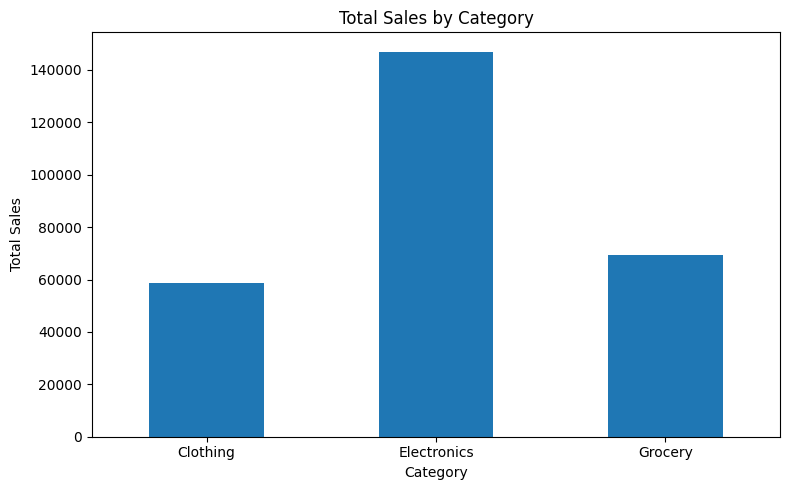

In [ ]:
import matplotlib.pyplot as plt

category_sales = df.groupby("Category")["Sales"].sum()

plt.figure(figsize=(8,5))
category_sales.plot(kind="bar")

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("sales_by_category.png")
plt.show()

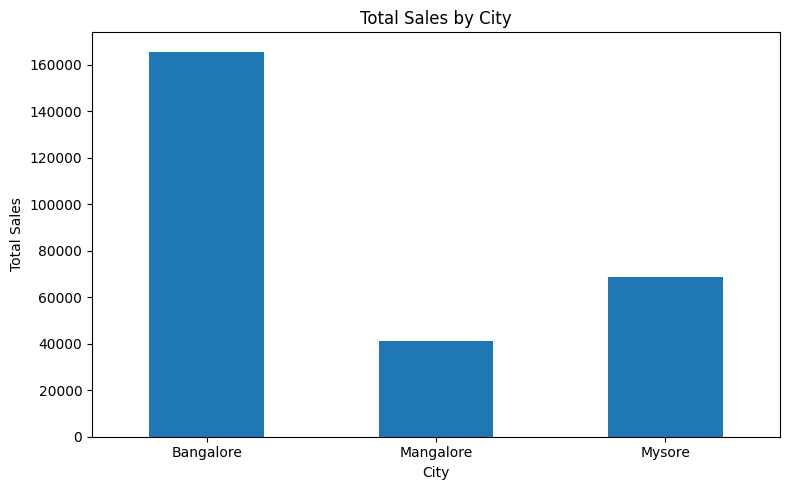

In [ ]:
city_sales = df.groupby("City")["Sales"].sum()

plt.figure(figsize=(8,5))
city_sales.plot(kind="bar")

plt.title("Total Sales by City")
plt.xlabel("City")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("sales_by_city.png")
plt.show()

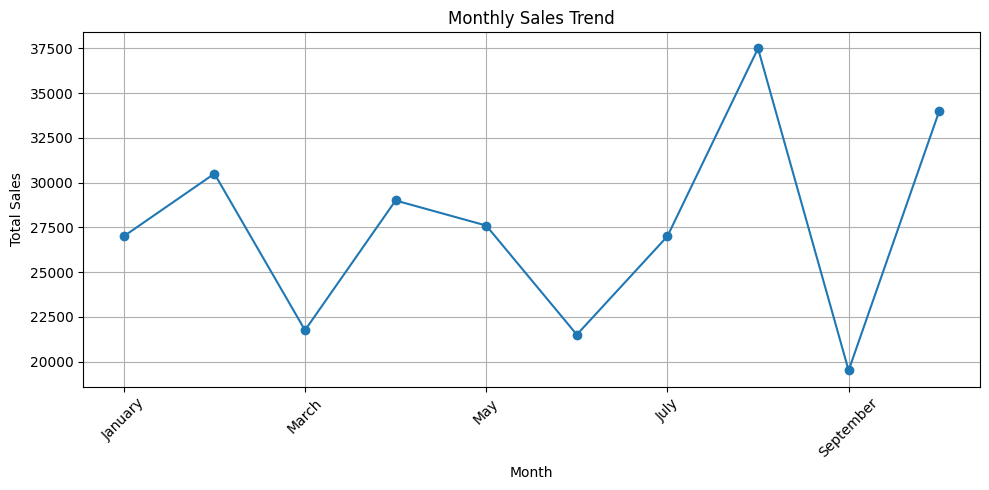

In [ ]:
month_order = [
    "January", "February", "March", "April", "May",
    "June", "July", "August", "September", "October"
]

monthly_sales = df.groupby("Month")["Sales"].sum()
monthly_sales = monthly_sales.reindex(month_order)

plt.figure(figsize=(10,5))
monthly_sales.plot(kind="line", marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.savefig("monthly_sales.png")
plt.show()

In [ ]:
print("================================================")
print("       DATA CLEANING & REPORTING AUTOMATION")
print("================================================")

print("\nDATA CLEANING RESULTS")
print("---------------------")
print("Final Records:", len(df))
print("Final Columns:", len(df.columns))
print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())

print("\nSALES REPORT")
print("---------------------")
print("Total Sales:", df["Sales"].sum())
print("Average Sales:", round(df["Sales"].mean(), 2))
print("Highest Sale:", df["Sales"].max())
print("Lowest Sale:", df["Sales"].min())

print("\nCATEGORY SUMMARY")
print("---------------------")
print(df.groupby("Category")["Sales"].sum())

print("\nCITY SUMMARY")
print("---------------------")
print(df.groupby("City")["Sales"].sum())

print("\nPROJECT STATUS")
print("---------------------")
print("✓ Data inspection completed")
print("✓ Missing values handled")
print("✓ Duplicate records removed")
print("✓ Inconsistent data standardized")
print("✓ Automated report generated")
print("✓ Visualizations generated")

print("\nProject completed successfully!")

       DATA CLEANING & REPORTING AUTOMATION

DATA CLEANING RESULTS
---------------------
Final Records: 20
Final Columns: 8
Missing Values: 0
Duplicate Rows: 0

SALES REPORT
---------------------
Total Sales: 275350.0
Average Sales: 13767.5
Highest Sale: 24000.0
Lowest Sale: 7600.0

CATEGORY SUMMARY
---------------------
Category
Clothing        58850.0
Electronics    147000.0
Grocery         69500.0
Name: Sales, dtype: float64

CITY SUMMARY
---------------------
City
Bangalore    165600.0
Mangalore     41000.0
Mysore        68750.0
Name: Sales, dtype: float64

PROJECT STATUS
---------------------
✓ Data inspection completed
✓ Missing values handled
✓ Duplicate records removed
✓ Inconsistent data standardized
✓ Automated report generated
✓ Visualizations generated

Project completed successfully!
